In [1]:
import pandas as pd
import numpy as np

In [2]:
data_path = "../data/raw/fairness_real_gender-hiring/GEMM_v3_5.csv"

df = pd.read_csv(data_path, low_memory=False)

print("Shape:", df.shape)
df.head()

Shape: (19181, 68)


,ID,country,pilot,f1_date,f1_channel,f1_type,f2_date,f2_channel,f2_type,f3_date,...,treat_warmth,religion,phenotype,headscarf,extrahsrel,extraprodgrade,response,response_col,anyinterest,invitation
0,1,United Kingdom,No,08aug2016,Email,Incomplete application,NaN,NaN,NaN,NaN,...,Yes,Christian,NaN,NaN,Cases follow GEMM design,NaN,Incomplete application,NaN,NaN,NaN
1,2,United Kingdom,No,14feb2017,Email,Additional information wanted,NaN,NaN,NaN,NaN,...,No,No religious affiliation,NaN,NaN,Cases follow GEMM design,NaN,Additional info wanted,Additional info wanted,Employer interested,No invitation
2,3,United Kingdom,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Yes,Christian,NaN,NaN,Cases follow GEMM design,NaN,No response,No response,Employer not interested,No invitation
3,4,United Kingdom,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,No,No religious affiliation,NaN,NaN,Cases follow GEMM design,NaN,No response,No response,Employer not interested,No invitation
4,5,United Kingdom,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,No,Muslim,NaN,NaN,Cases follow GEMM design,NaN,No response,No response,Employer not interested,No invitation


In [3]:
# inspect available variables
print(df.columns.tolist())
print()
print(df.dtypes)

['ID', 'country', 'pilot', 'f1_date', 'f1_channel', 'f1_type', 'f2_date', 'f2_channel', 'f2_type', 'f3_date', 'f3_channel', 'f3_type', 'f4_date', 'f4_channel', 'f4_type', 'f5_date', 'f5_channel', 'f5_type', 'f6_date', 'f6_channel', 'f6_type', 'f7_date', 'f7_channel', 'f7_type', 'f8_date', 'f8_channel', 'f8_type', 'f9_date', 'f9_channel', 'f9_type', 'f10_date', 'f10_channel', 'f10_type', 'f11_date', 'f11_channel', 'f11_type', 'occupation', 'app_retrieved', 'app_published', 'app_sent', 'app_sent_channel', 'wp_nuts2', 'wp_nuts3', 'comp_size', 'equal', 'anonym', 'wantsalary', 'responsible', 'worktype', 'fullname', 'gender', 'grade', 'qualmismatch', 'migrationstatus', 'ethnicity', 'native', 'ethnicity7', 'treat_perf', 'treat_warmth', 'religion', 'phenotype', 'headscarf', 'extrahsrel', 'extraprodgrade', 'response', 'response_col', 'anyinterest', 'invitation']

ID                 int64
country           object
pilot             object
f1_date           object
f1_channel        object
        

In [4]:
dag_columns = [
    "gender",
    "invitation",
    "country",
    "occupation",
    "qualmismatch"
]

df_gemm = df[dag_columns].copy()

df_gemm.head()

,gender,invitation,country,occupation,qualmismatch
0,Female,NaN,United Kingdom,Receptionist,Fit
1,Female,No invitation,United Kingdom,Cook,Fit
2,Female,No invitation,United Kingdom,Software Developer,Fit
3,Male,No invitation,United Kingdom,Software Developer,Overqualified
4,Female,No invitation,United Kingdom,Sales Representative,Fit


In [5]:
# inspect DAG variables
for col in dag_columns:
    print(f"\n{col}:")
    print(df_gemm[col].value_counts(dropna=False))


gender:
gender
Female    9722
Male      9407
NaN         52
Name: count, dtype: int64

invitation:
invitation
No invitation    14319
Invitation        4571
NaN                291
Name: count, dtype: int64

country:
country
Spain             5293
Netherlands       4463
United Kingdom    3339
Germany           3234
Norway            2852
Name: count, dtype: int64

occupation:
occupation
Cook                    3756
Payroll Clerk           3363
Sales Representative    2645
Store Assistant         2592
Software Developer      2255
Receptionist            2033
Hairdresser             1454
Electrician              395
Carpenter                391
Plumber                  245
NaN                       52
Name: count, dtype: int64

qualmismatch:
qualmismatch
Fit               12747
Overqualified      4367
Underqualified     1610
NaN                 457
Name: count, dtype: int64


In [6]:
# remove rows with missing gender or invitation
df_clean = df_gemm.dropna(
    subset=["gender", "invitation"]
).copy()

print("Before cleaning:", len(df_gemm))
print("After cleaning:", len(df_clean))

Before cleaning: 19181
After cleaning: 18890


In [7]:
# encode exposure and outcome
df_clean["female"] = (df_clean["gender"] == "Female").astype(int)
df_clean["invited"] = (df_clean["invitation"] == "Invitation").astype(int)

df_clean[["gender", "female", "invitation", "invited"]].head()

,gender,female,invitation,invited
1,Female,1,No invitation,0
2,Female,1,No invitation,0
3,Male,0,No invitation,0
4,Female,1,No invitation,0
5,Female,1,Invitation,1


In [8]:
# invitation rate by gender
invitation_rates = df_clean.groupby("gender")["invited"].mean()

print(invitation_rates.round(3))

gender
Female    0.250
Male      0.233
Name: invited, dtype: float64


In [9]:
# naive gender difference in invitation probability
female_rate = invitation_rates.loc["Female"]
male_rate = invitation_rates.loc["Male"]

naive_difference = female_rate - male_rate

print(f"Female invitation rate: {female_rate:.3f}")
print(f"Male invitation rate:   {male_rate:.3f}")
print(f"Difference:              {naive_difference:.3f}")

Female invitation rate: 0.250
Male invitation rate:   0.233
Difference:              0.017


In [10]:
from dowhy import CausalModel

graph = """
digraph {
    female -> invited;

    country -> occupation;
    country -> invited;

    occupation -> invited;

    qualmismatch -> invited;
}
"""

In [11]:
model = CausalModel(
    data=df_clean,
    treatment="female",
    outcome="invited",
    graph=graph
)

identified_estimand = model.identify_effect()

print(identified_estimand)
print("Backdoor variables:", identified_estimand.get_backdoor_variables())

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                
─────────(E[invited])
d[female]            
Estimand assumption 1, Unconfoundedness: If U→{female} and U→invited then P(invited|female,,U) = P(invited|female,)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
    d                
─────────(E[invited])
d[female]            
Estimand assumption 1, Unconfoundedness: If U→{female} and U→invited then P(invited|female,,U) = P(invited|female,)

Backdoor variables: []


In [12]:
causal_estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
    control_value=0,
    treatment_value=1
)

print(f"Naive associational difference: {naive_difference:.3f}")
print(f"Estimated causal effect:        {causal_estimate.value:.3f}")

Naive associational difference: 0.017
Estimated causal effect:        0.016


c:\Users\andre\AppData\Local\Programs\Python\Python311\Lib\site-packages\dowhy\causal_estimator.py:272: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conditional_estimates = by_effect_mods.apply(estimate_effect_fn)


In [13]:
# add an irrelevant random variable
refute_random = model.refute_estimate(
    identified_estimand,
    causal_estimate,
    method_name="random_common_cause"
)

print(refute_random)

c:\Users\andre\AppData\Local\Programs\Python\Python311\Lib\site-packages\dowhy\causal_estimator.py:272: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conditional_estimates = by_effect_mods.apply(estimate_effect_fn)
c:\Users\andre\AppData\Local\Programs\Python\Python311\Lib\site-packages\dowhy\causal_estimator.py:272: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conditional_estimates = by_effect_mods.apply(estimate_e

Refute: Add a random common cause
Estimated effect:0.01638527057973324
New effect:0.01638382900512119
p value:0.96



c:\Users\andre\AppData\Local\Programs\Python\Python311\Lib\site-packages\dowhy\causal_estimator.py:272: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conditional_estimates = by_effect_mods.apply(estimate_effect_fn)


In [14]:
# replace gender with a random placebo
refute_placebo = model.refute_estimate(
    identified_estimand,
    causal_estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute"
)

print(refute_placebo)

c:\Users\andre\AppData\Local\Programs\Python\Python311\Lib\site-packages\dowhy\causal_estimator.py:272: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conditional_estimates = by_effect_mods.apply(estimate_effect_fn)
c:\Users\andre\AppData\Local\Programs\Python\Python311\Lib\site-packages\dowhy\causal_estimator.py:272: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conditional_estimates = by_effect_mods.apply(estimate_e

Refute: Use a Placebo Treatment
Estimated effect:0.01638527057973324
New effect:-0.0011036099590399741
p value:0.82



c:\Users\andre\AppData\Local\Programs\Python\Python311\Lib\site-packages\dowhy\causal_estimator.py:272: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conditional_estimates = by_effect_mods.apply(estimate_effect_fn)


In [15]:
# repeat estimation on a subset of the data
refute_subset = model.refute_estimate(
    identified_estimand,
    causal_estimate,
    method_name="data_subset_refuter",
    subset_fraction=0.8
)

print(refute_subset)

c:\Users\andre\AppData\Local\Programs\Python\Python311\Lib\site-packages\dowhy\causal_estimator.py:272: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conditional_estimates = by_effect_mods.apply(estimate_effect_fn)
c:\Users\andre\AppData\Local\Programs\Python\Python311\Lib\site-packages\dowhy\causal_estimator.py:272: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conditional_estimates = by_effect_mods.apply(estimate_e

Refute: Use a subset of data
Estimated effect:0.01638527057973324
New effect:0.0164769495987766
p value:0.94



c:\Users\andre\AppData\Local\Programs\Python\Python311\Lib\site-packages\dowhy\causal_estimator.py:272: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conditional_estimates = by_effect_mods.apply(estimate_effect_fn)


In [16]:
# summarize main results
results = pd.DataFrame({
    "Method": [
        "Naive association",
        "Causal estimate"
    ],
    "Effect": [
        naive_difference,
        causal_estimate.value
    ]
})

results["Effect"] = results["Effect"].round(3)

results

,Method,Effect
0,Naive association,0.017
1,Causal estimate,0.016


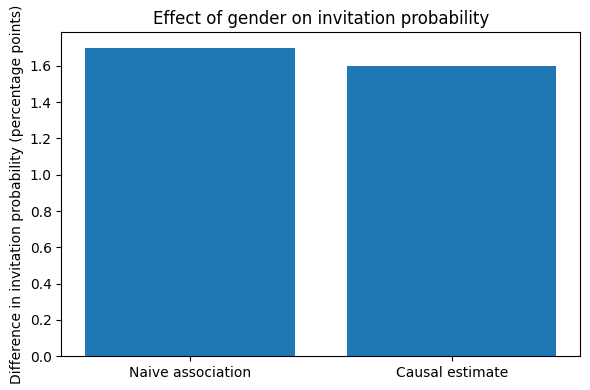

In [17]:
import matplotlib.pyplot as plt

# convert effects to percentage points
results["Effect_pp"] = results["Effect"] * 100

plt.figure(figsize=(6, 4))

plt.bar(
    results["Method"],
    results["Effect_pp"]
)

plt.ylabel("Difference in invitation probability (percentage points)")
plt.title("Effect of gender on invitation probability")

plt.tight_layout()
plt.show()

### Interpretation

Female applicants had an observed invitation probability approximately 1.7 percentage points higher than male applicants. The causal estimate was approximately +1.6 percentage points and was therefore almost identical to the naive associational difference.

According to the specified DAG, there are no open backdoor paths between gender and invitation, so no confounder adjustment is required for this effect. In this case, causal analysis therefore supports rather than substantially changes the associational conclusion.

The refutation checks also indicated a stable estimate: adding an irrelevant random variable produced almost no change, the placebo treatment produced an effect close to zero, and estimation on an 80% subset produced a very similar result.

## Heterogeneity Check by Country

The pooled gender effect may conceal differences between national hiring contexts. Invitation rates are therefore compared separately by country to examine whether the direction and magnitude of the observed gender difference are consistent across the five countries.

In [18]:
# invitation rates by country and gender
country_rates = (
    df_clean
    .groupby(["country", "gender"])["invited"]
    .mean()
    .unstack()
)

country_rates["Difference"] = (
    country_rates["Female"] - country_rates["Male"]
)

country_results = country_rates.rename(columns={
    "Female": "Female invitation rate",
    "Male": "Male invitation rate"
})

country_results["Difference (pp)"] = country_results["Difference"] * 100

country_results[
    [
        "Female invitation rate",
        "Male invitation rate",
        "Difference (pp)"
    ]
].round(3)

gender,Female invitation rate,Male invitation rate,Difference (pp)
country,,,
Germany,0.351,0.327,2.414
Netherlands,0.365,0.358,0.655
Norway,0.191,0.177,1.422
Spain,0.214,0.188,2.569
United Kingdom,0.101,0.099,0.193


### Country-Level Heterogeneity Interpretation

The invitation-rate difference between female and male applicants was positive in all five countries, but its magnitude varied across national contexts. The largest differences were observed in Spain (+2.569 percentage points) and Germany (+2.414 percentage points), while the difference was substantially smaller in the Netherlands (+0.655 percentage points) and the United Kingdom (+0.193 percentage points).

This indicates that the pooled gender effect does not fully describe the variation across countries. However, these subgroup differences are descriptive and may partly reflect sampling variability. They should therefore not be interpreted as evidence that the true causal effect necessarily differs between countries without further statistical analysis.